# Applying MLP for Travel Recommendations

In [ ]:
# load google directory
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# keras contains the tensorflow package, often used for fitting NNets
from keras.models import Model
from keras.layers import Dense, Input
from keras.optimizers import SGD

### 1: Data Preprocessing

In [ ]:
# connect to google drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# load date
df = pd.read_csv('/content/drive/MyDrive/fourth year/DS 4420/travel_data.csv')

FEATURES = ['culture', 'adventure', 'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion']
X_raw = df[FEATURES].values.astype(float)

X_raw

array([[5., 2., 2., ..., 3., 5., 2.],
       [2., 4., 5., ..., 4., 1., 5.],
       [3., 5., 5., ..., 4., 2., 4.],
       ...,
       [4., 2., 2., ..., 3., 4., 2.],
       [5., 2., 3., ..., 3., 5., 2.],
       [4., 3., 3., ..., 2., 2., 4.]])

In [ ]:
# encode region labels as integers and one-hot vectors
region_codes, region_labels = pd.factorize(df['region'])
n_classes = len(region_labels)
Y = pd.get_dummies(df['region']).values.astype(float)
Y

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [ ]:
# normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

In [ ]:
# train / validation split (80/20), maintain region ratios
X_train, X_val, y_train, y_val = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=region_codes)

### 2: Build & Fit MLP Model

General Architecture:
**9 inputs → 64 hidden nodes (ReLU) → 7 output classes (softmax)**

In [ ]:
inpx = Input(shape=(len(FEATURES),))

In [ ]:
# hidden layer with ReLU activation function
hid = Dense(64, activation='relu')(inpx)

In [ ]:
# output layer - softmax converts scores to probabilities
out_layer = Dense(n_classes, activation='softmax')(hid)

In [ ]:
# fit the model
model = Model([inpx], out_layer)

model.compile(
    optimizer=SGD(learning_rate=0.05),
    loss='categorical_crossentropy', # categorical version of MSE loss function
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=500, batch_size=len(X_train),
          validation_data=(X_val, y_val), verbose=0)

### 3: Evaluate MLP Model

In [ ]:
score = model.evaluate(X_val, y_val, verbose=0)
print('loss=', score[0])
print('accuracy=', score[1])

loss= 1.4549055099487305
accuracy= 0.4732142984867096


Model accuracy performance is low; however, this is okay because we are using this model mainly to understand feature importance. The MLP model output is simply a means to an end (i.e., arbitrary). The real assessment will come later!

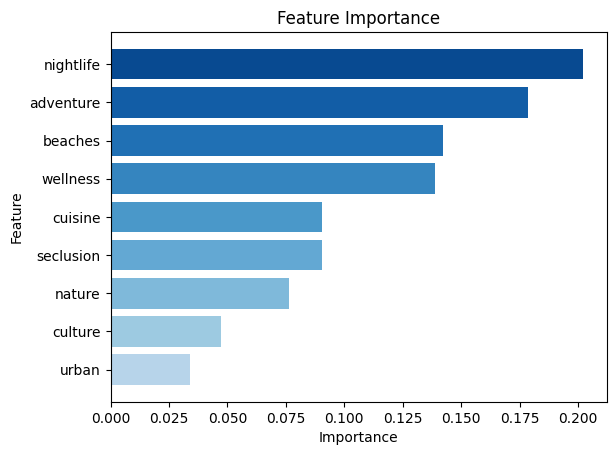

In [ ]:
# what features were most important?

W1 = model.layers[1].get_weights()[0]
W2 = model.layers[2].get_weights()[0]

# for each input feature i, importance = sum of |W1[i,j] * W2[j,k]| over all hidden nodes j and output classes k
connection = W1 @ W2
importance = np.abs(connection).sum(axis=1)
importance = importance / importance.sum()

importance_series = pd.Series(importance, index=FEATURES).sort_values(ascending=False)

colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(importance_series))) # making this pretty for the paper :)
plt.barh(importance_series.index[::-1], importance_series.values[::-1],color=colors)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

### 4: Extract Hidden Vectors

After training, the model has learned to compress each city's 9 feature scores into a 64-dimensional hidden vector (post activation values of the hidden layer). Each of the 64 values in that vector represents some learned combination of the original features. This is essentially the network's internal representation of what makes each city similar or different from others.

The reason we extract these vectors instead of using the raw features directly is that the network has done something non-linear with them: it learned relationships between features that a simple distance calculation on the raw scores wouldn't capture. For example, a city that is high on nature and seclusion together might be fundamentally different from one that is high on nature and urban together, even if their raw Euclidean distances look similar.

*This enables us to find cities that the network thinks are structurally similar, which is a richer notion of similarity than just comparing raw scores. The importance plot above directly relates to these as well since it shows which features are driving the similarity structure (hidden vectors).*

In [ ]:
hidden_model = Model(inputs=model.input, outputs=model.layers[1].output)
hidden_vecs = hidden_model.predict(X, verbose=0)

###

### 5: Making Recommendations

Now, to get back to the reason we are here. Let's figure out where we should travel to next and build a recommendation system, using what our machine learning model has learned (the hidden vectors).

The approach is simple:
1. Look up the hidden vector of a given city
2. Compute euclidean distance to every other city's hidden vector
3. Return the top n closest cities



In [ ]:
def recommend(city, top_n=5):

  # find the given city
  idx = df.index[df['city'] == city].tolist()
  if not idx:
      return print(f"'{city}' not found.")

  # calculate the euclidian distance
  vec = hidden_vecs[idx[0]]
  diffs = hidden_vecs - vec
  dists = np.sqrt((diffs ** 2).sum(axis=1))

  # sort to get the top n
  ranked = np.argsort(dists)
  ranked = ranked[ranked != idx[0]]

  # pretty output !
  print(f'Cities most similar to: {city}')
  for rank_idx in ranked[:top_n]:
      row = df.iloc[rank_idx]
      print(f"  {row['city']}, {row['country']} ({dists[rank_idx]:.3f})")

In [ ]:
# let's do an example: say Paris
recommend('Paris')

Cities most similar to: Paris
  Vienna, Austria (1.333)
  London, United Kingdom (1.782)
  Seoul, South Korea (2.051)
  Mexico City, Mexico (2.571)
  Lyon, France (2.615)


In [ ]:
# how about another one
recommend('Hanoi')

Cities most similar to: Hanoi
  Puebla, Mexico (0.000)
  Lahore, Pakistan (1.187)
  Chengdu, China (1.193)
  Tehran, Iran (1.347)
  Guanajuato, Mexico (1.347)


### 6: Evaluate Our Recommendation System

To check whether or not our recommendations make sense inuitively, we are performing a qualitative check by randomly selecting 10 cities, and then plot each city's feature scores. If our model is doing well, we should see similar ratings across the features.

In [ ]:
# generate random sample
np.random.seed(42)
sample_cities = df['city'].sample(10).tolist()
print(sample_cities)

['Cork', 'Gorée Island', 'Seville', 'Helsinki', 'Essaouira', 'Krakow', 'Port Vila', 'Sal', 'Jeju Island', 'Ha Long']


Cities most similar to: Cork
  Bandung, Indonesia (0.000)
  Paramaribo, Suriname (0.000)
  Granada, Nicaragua (0.000)
  Rijeka, Croatia (0.795)
  Mostar, Bosnia and Herzegovina (0.849)


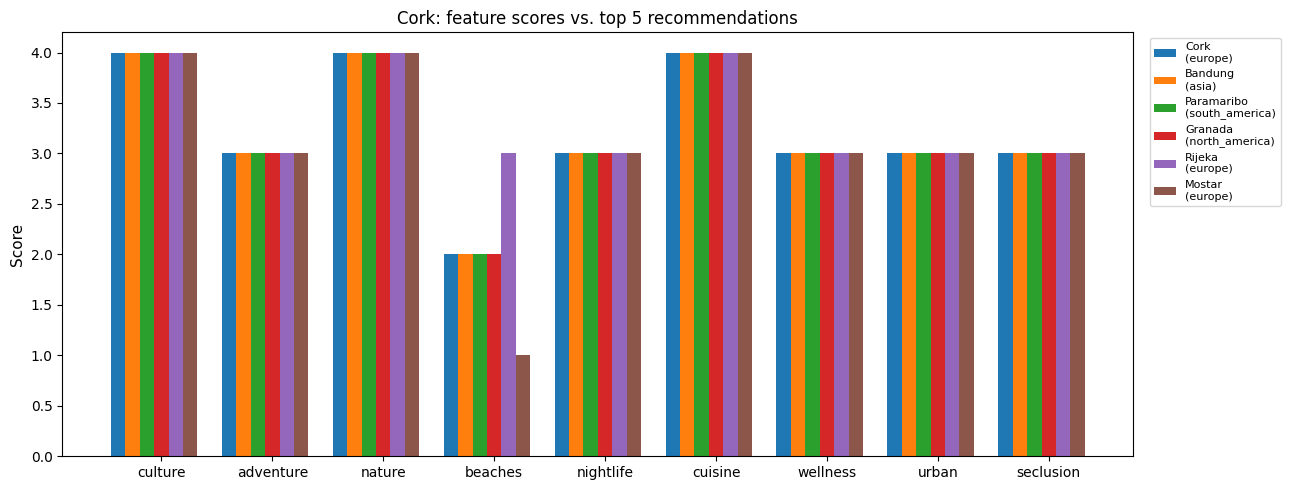

Cities most similar to: Gorée Island
  Khiva, Uzbekistan (1.996)
  Bukhara, Uzbekistan (2.501)
  San Marino, San Marino (2.581)
  Bagan, Myanmar (2.695)
  Sighisoara, Romania (2.715)


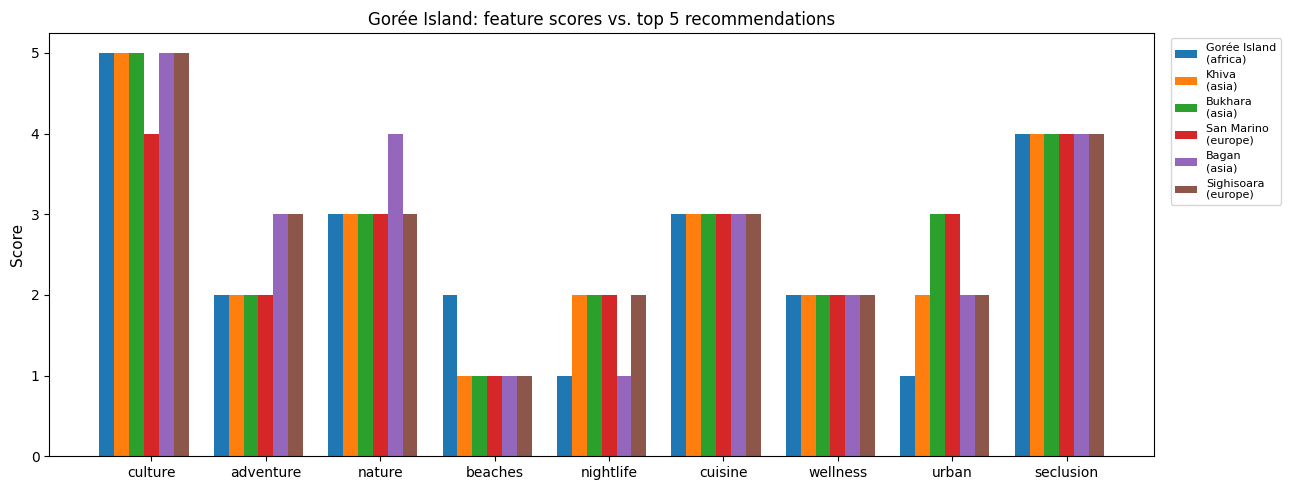

Cities most similar to: Seville
  Guadalajara, Mexico (1.107)
  Lahore, Pakistan (1.398)
  New Orleans, United States (1.442)
  Lima, Peru (1.453)
  Granada, Spain (1.453)


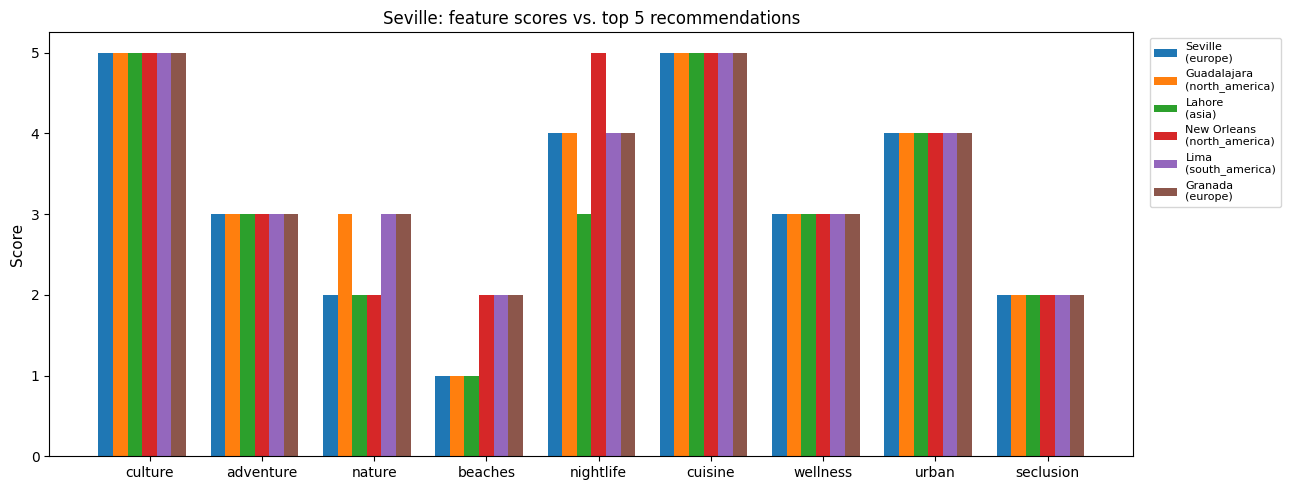

Cities most similar to: Helsinki
  Oslo, Norway (0.000)
  Portland, United States (0.000)
  Bern, Switzerland (0.742)
  Lausanne, Switzerland (0.742)
  Zurich, Switzerland (1.680)


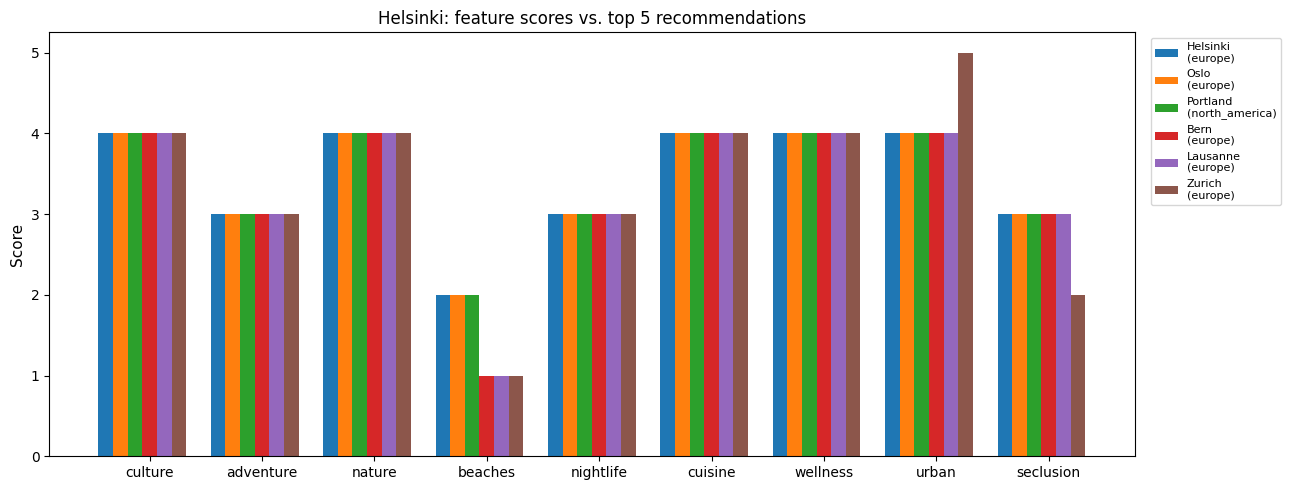

Cities most similar to: Essaouira
  Piran, Slovenia (0.000)
  Ajaccio, France (0.000)
  Zanzibar Town, Tanzania (0.792)
  Nafplio, Greece (0.831)
  Adelaide, Australia (0.831)


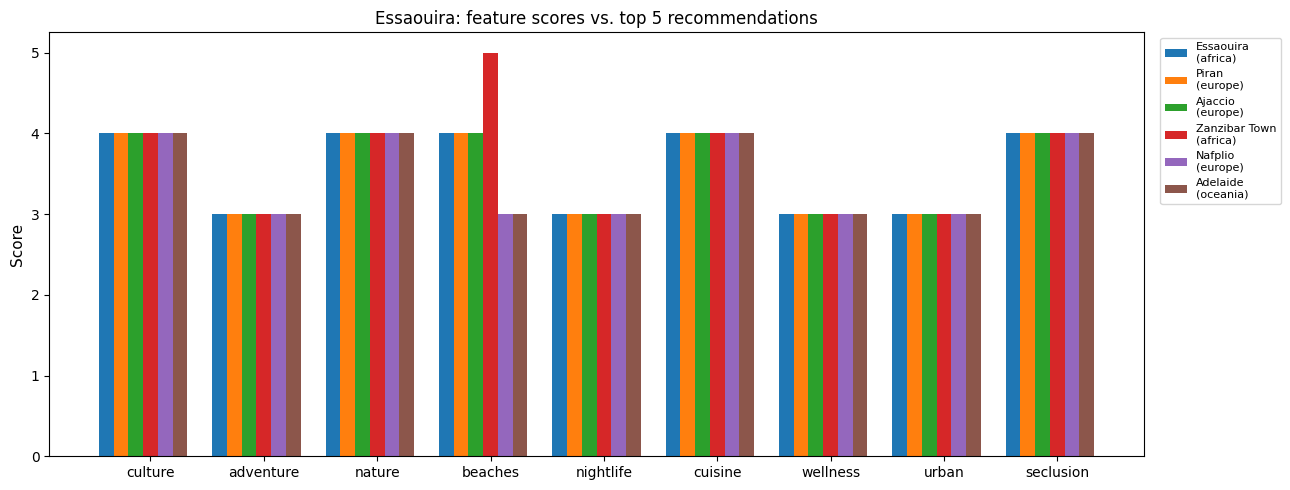

Cities most similar to: Krakow
  Kraków, Poland (0.000)
  Ghent, Belgium (0.000)
  Prague, Czech Republic (0.944)
  Washington, United States (0.944)
  St Petersburg, Russia (0.944)


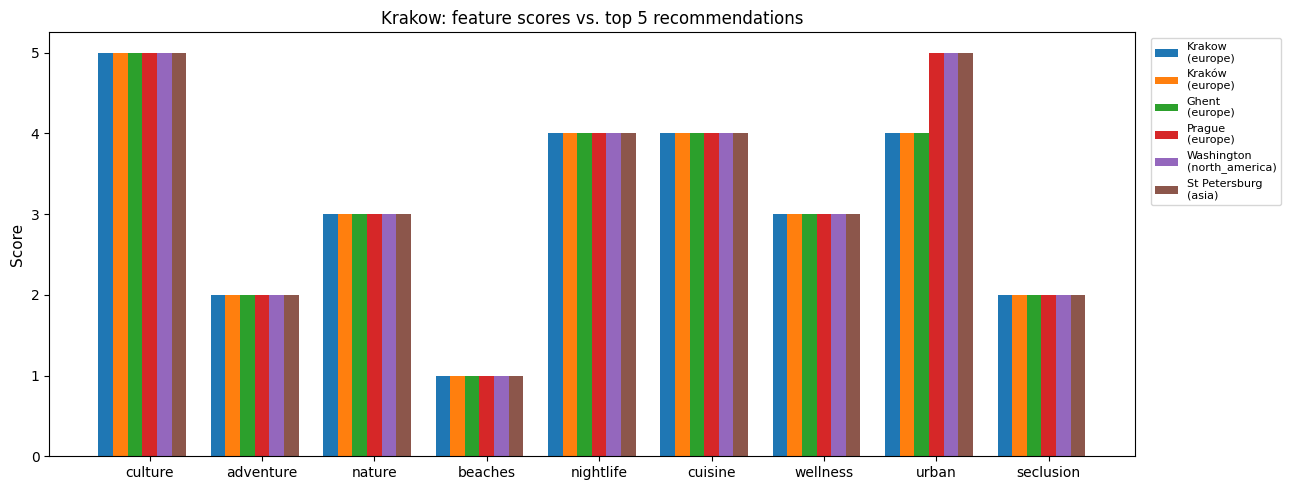

Cities most similar to: Port Vila
  Vancouver Island, Canada (0.000)
  La Palma, Spain (0.860)
  Roseau, Dominica (0.860)
  Nadi, Fiji (1.086)
  Rarotonga, Cook Islands (1.136)


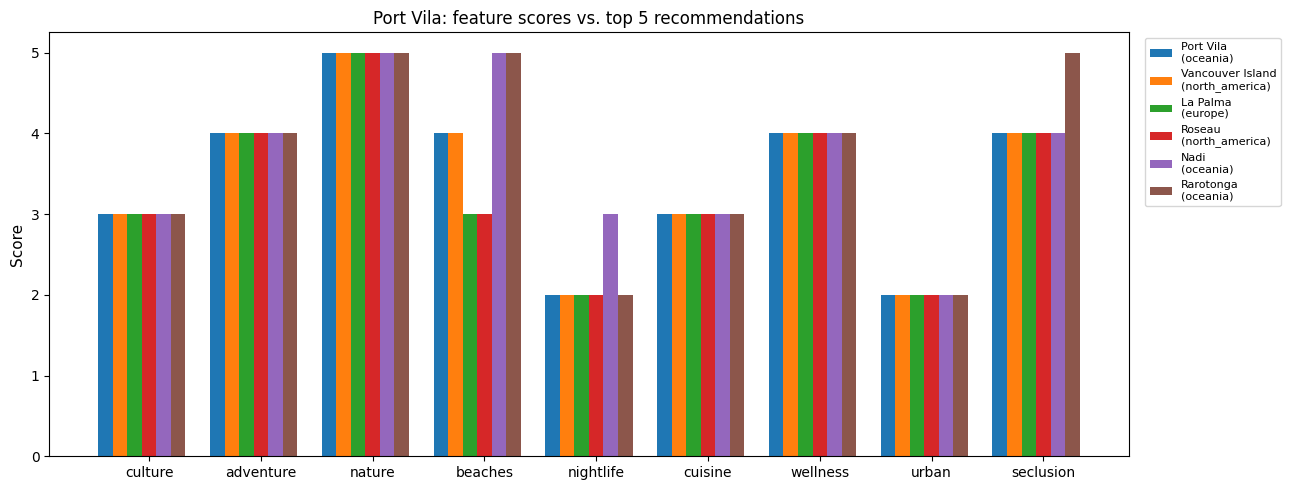

Cities most similar to: Sal
  San Andrés, Colombia (1.849)
  Nukuʻalofa, Tonga (2.068)
  Avarua, Cook Islands (2.298)
  Lautoka, Fiji (2.501)
  Providenciales, Turks and Caicos (2.622)


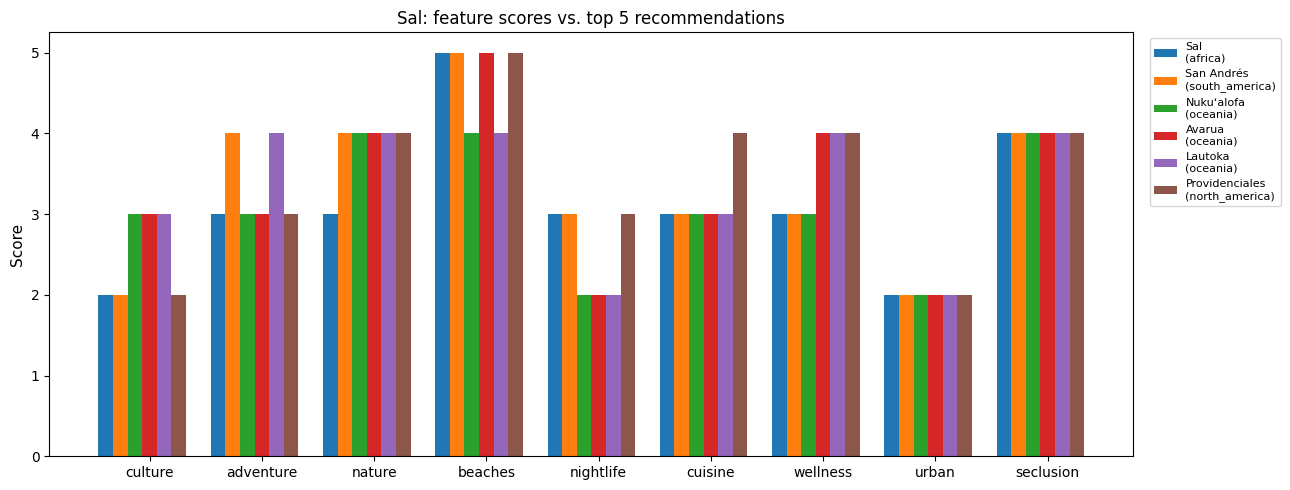

Cities most similar to: Jeju Island
  Maui, United States (0.781)
  Victoria, Seychelles (0.781)
  Krabi, Thailand (0.781)
  Madeira, Portugal (1.112)
  Papeete, French Polynesia (1.263)


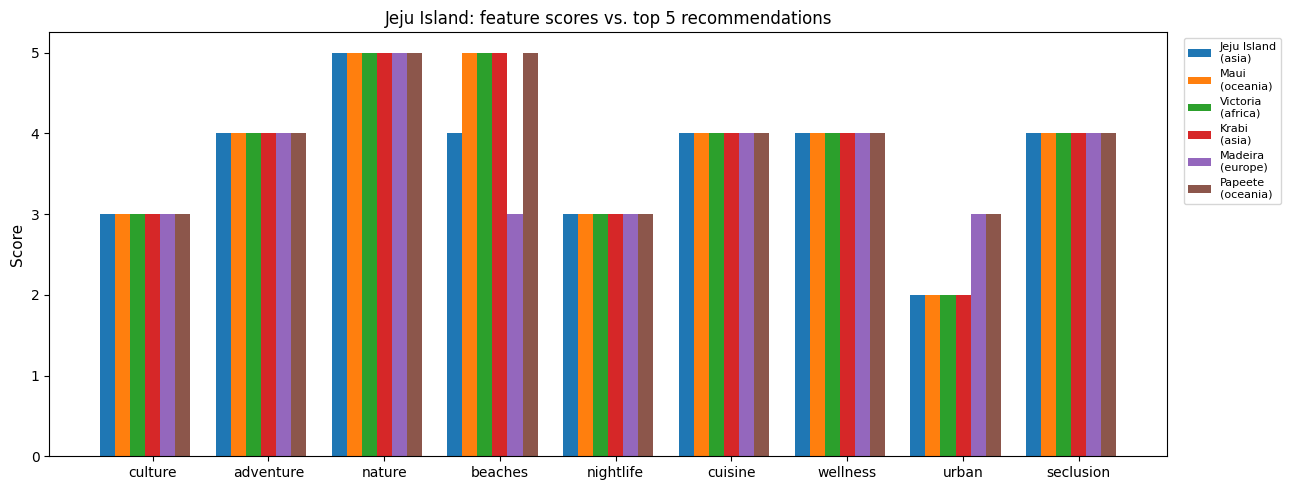

Cities most similar to: Ha Long
  Azores, Portugal (0.867)
  Hualien, Taiwan (0.912)
  Asturias, Spain (1.430)
  Davao, Philippines (1.438)
  Annecy, France (1.593)


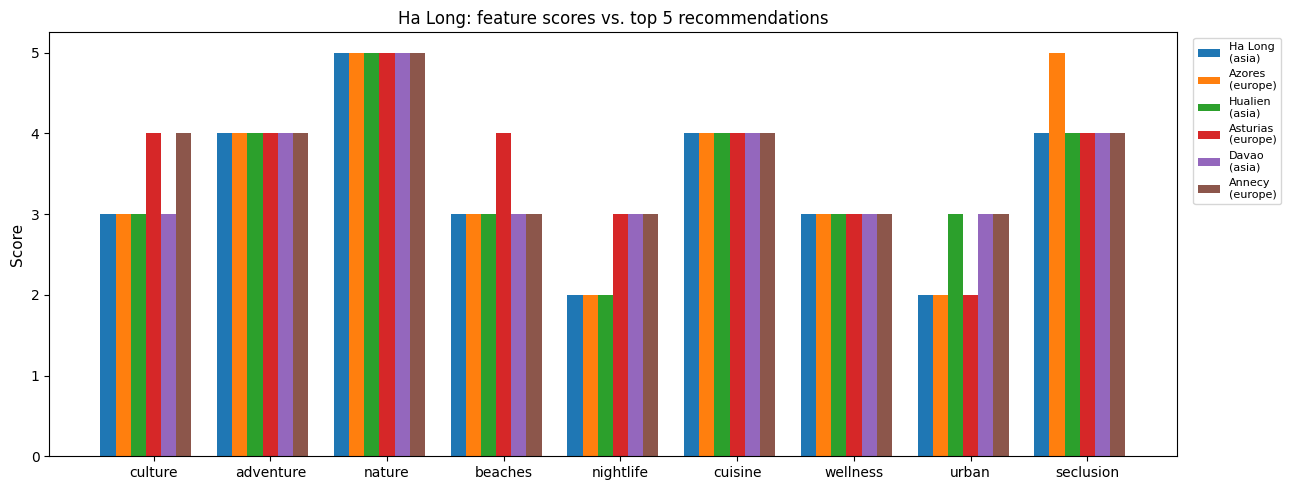

In [ ]:
# compare cities with each other by their features
for city in sample_cities:
    idx = df.index[df['city'] == city].tolist()[0]

    # get top 5 recommendations
    query_vec = hidden_vecs[idx]
    diffs = hidden_vecs - query_vec
    dists = np.sqrt((diffs ** 2).sum(axis=1))
    ranked = np.argsort(dists)
    ranked = ranked[ranked != idx][:5]
    recommend(city)

    # build a dataframe with the query city and its top 5 recommendations
    rows = [df.iloc[idx]] + [df.iloc[i] for i in ranked]
    labels = [f"{r['city']}\n({r['region']})" for r in rows]
    scores = np.array([r[FEATURES].values for r in rows])

    # make a pretty plot
    x = np.arange(len(FEATURES))
    width = 0.13
    fig, ax = plt.subplots(figsize=(13, 5))

    for i, (label, score_row) in enumerate(zip(labels, scores)):
        offset = (i - len(rows) / 2) * width
        ax.bar(x + offset, score_row, width, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels(FEATURES, fontsize=10)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{city}: feature scores vs. top 5 recommendations', fontsize=12)
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()